# EDA: creditcard.csv

All data processing is delegated to `src.data_processing`. This notebook only visualises the results.

In [1]:
import sys
from pathlib import Path

proj_root = Path.cwd().resolve().parent
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from src.data_processing import (
    load_creditcard_data, handle_cleaning, check_missing_values,
    check_duplicates, get_class_distribution,
)

sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

## 1. Load & Clean

In [2]:
df = load_creditcard_data()
print(f"Shape: {df.shape}")
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
missing = check_missing_values(df)
print("Missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "None found")

Missing values:
None found


In [5]:
dupes = check_duplicates(df)
print(f"Duplicate rows: {len(dupes)} ({len(dupes)/len(df)*100:.2f}%)")
print("sample of duplicate rows:")
print(dupes.dtypes)

df = handle_cleaning(df)
print(f"Shape after cleaning: {df.shape}")

Duplicate rows: 1081 (0.38%)
sample of duplicate rows:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount  

## 2. Class Imbalance


Class Distribution (Credit Card):
  Class 0: 283,253 (99.83%)
  Class 1: 473 (0.17%)
  Imbalance Ratio: 598.8:1


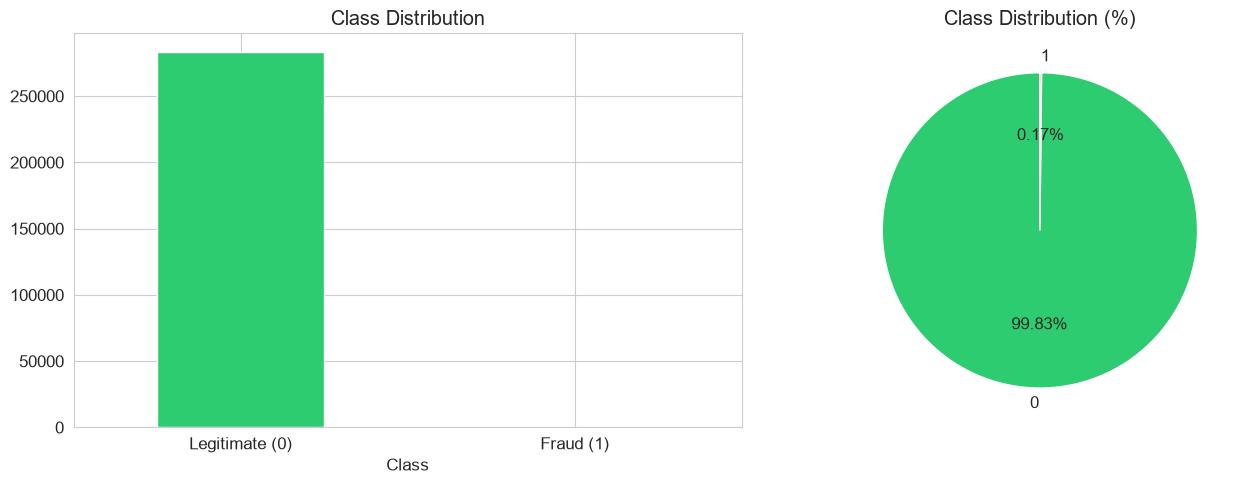

In [6]:
dist = get_class_distribution(df["Class"], name="(Credit Card)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df["Class"].value_counts()
counts.plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_xticklabels(["Legitimate (0)", "Fraud (1)"], rotation=0)
axes[0].set_title("Class Distribution")

counts.plot.pie(ax=axes[1], colors=["#2ecc71", "#e74c3c"], autopct="%1.2f%%", startangle=90)
axes[1].set_ylabel("")
axes[1].set_title("Class Distribution (%)")
plt.tight_layout()
plt.show()

## 3. Amount Analysis

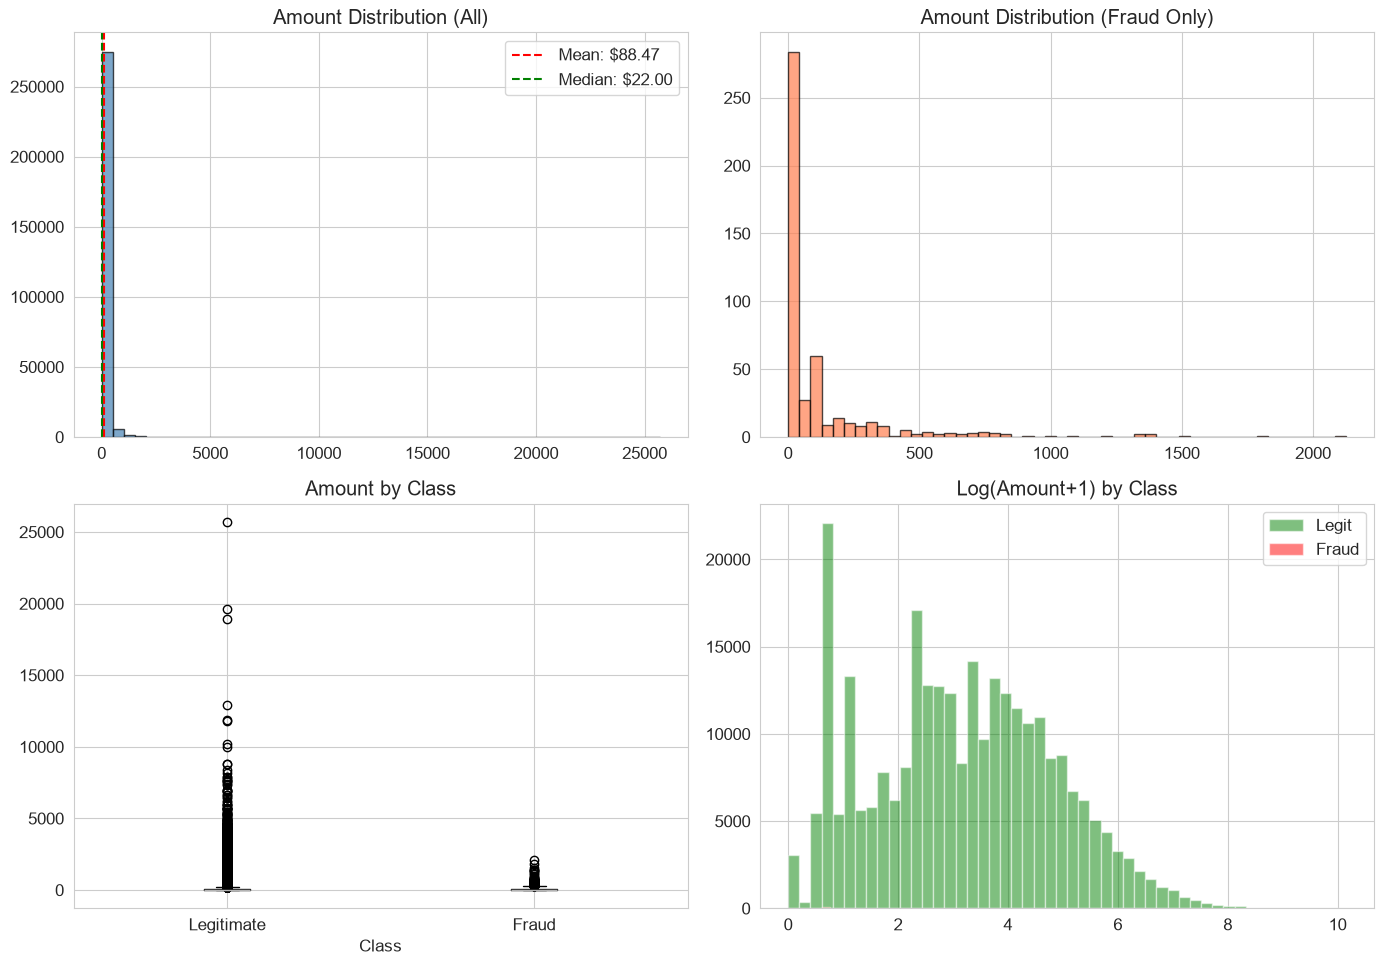


Amount Stats by Class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["Amount"], bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[0, 0].axvline(df["Amount"].mean(), color="red", ls="--", label=f'Mean: ${df["Amount"].mean():.2f}')
axes[0, 0].axvline(df["Amount"].median(), color="green", ls="--", label=f'Median: ${df["Amount"].median():.2f}')
axes[0, 0].legend()
axes[0, 0].set_title("Amount Distribution (All)")

fraud_amt = df[df["Class"] == 1]["Amount"]
axes[0, 1].hist(fraud_amt, bins=50, edgecolor="black", alpha=0.7, color="coral")
axes[0, 1].set_title("Amount Distribution (Fraud Only)")

df.boxplot(column="Amount", by="Class", ax=axes[1, 0])
axes[1, 0].set_title("Amount by Class")
axes[1, 0].set_xticklabels(["Legitimate", "Fraud"])
plt.suptitle("")

# Log-transformed
amt_log = np.log1p(df["Amount"])
axes[1, 1].hist(amt_log[df["Class"] == 0], bins=50, alpha=0.5, label="Legit", color="green")
axes[1, 1].hist(amt_log[df["Class"] == 1], bins=50, alpha=0.5, label="Fraud", color="red")
axes[1, 1].set_title("Log(Amount+1) by Class")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nAmount Stats by Class:")
print(df.groupby("Class")["Amount"].describe())

## 4. Time Analysis

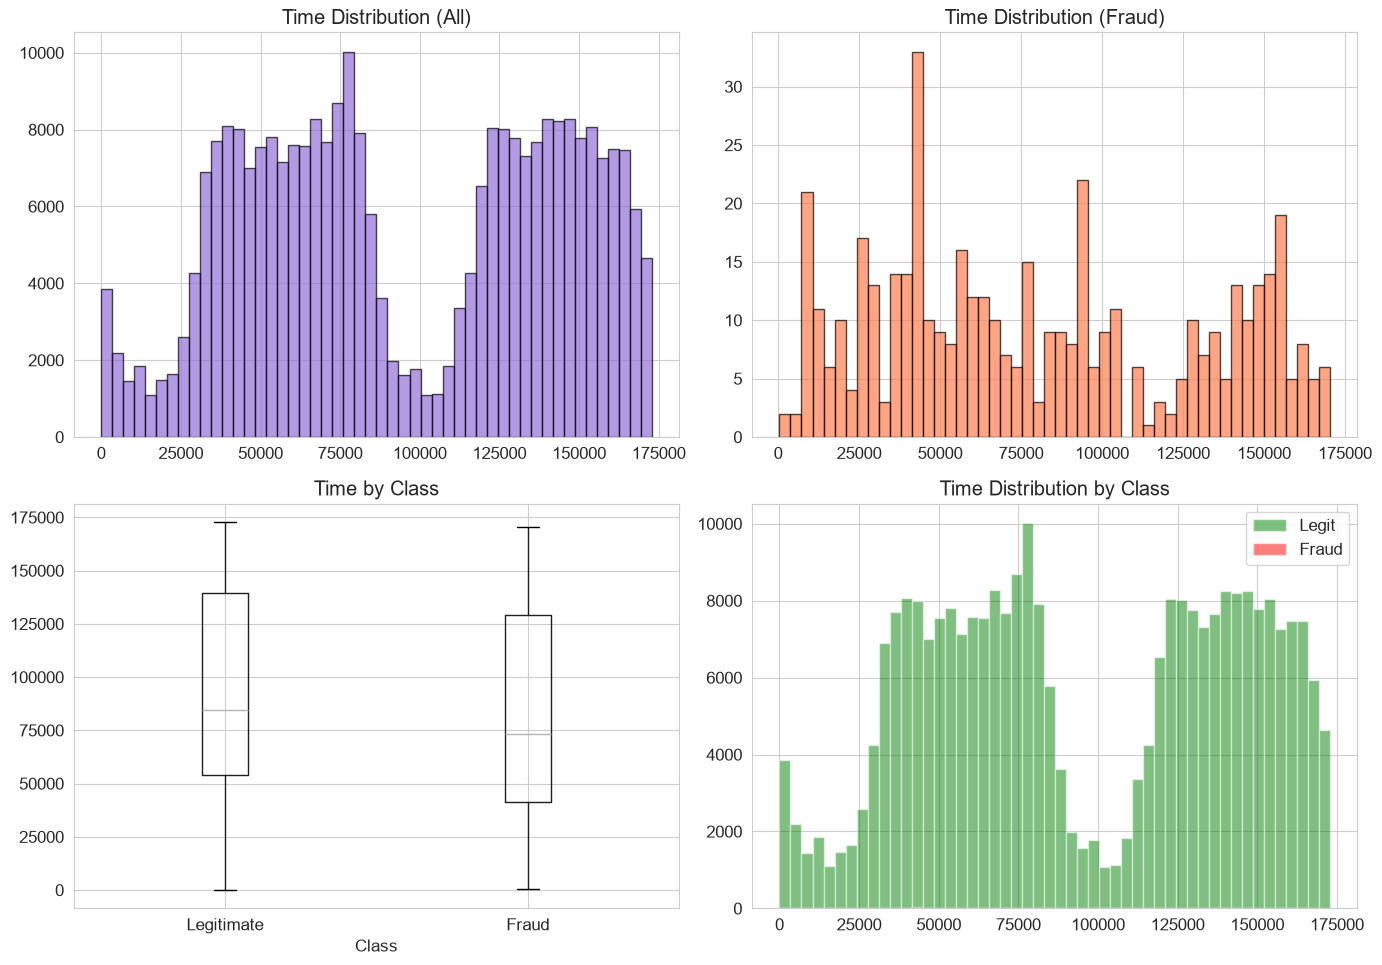


Time Stats by Class:
          count          mean           std    min      25%      50%  \
Class                                                                  
0      283253.0  94835.058093  47475.550607    0.0  54233.0  84711.0   
1         473.0  80450.513742  48636.179973  406.0  41203.0  73408.0   

            75%       max  
Class                      
0      139308.0  172792.0  
1      129095.0  170348.0  


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["Time"], bins=50, edgecolor="black", alpha=0.7, color="mediumpurple")
axes[0, 0].set_title("Time Distribution (All)")

axes[0, 1].hist(df[df["Class"] == 1]["Time"], bins=50, edgecolor="black", alpha=0.7, color="coral")
axes[0, 1].set_title("Time Distribution (Fraud)")

df.boxplot(column="Time", by="Class", ax=axes[1, 0])
axes[1, 0].set_title("Time by Class")
axes[1, 0].set_xticklabels(["Legitimate", "Fraud"])
plt.suptitle("")

axes[1, 1].hist(df[df["Class"] == 0]["Time"], bins=50, alpha=0.5, label="Legit", color="green")
axes[1, 1].hist(df[df["Class"] == 1]["Time"], bins=50, alpha=0.5, label="Fraud", color="red")
axes[1, 1].set_title("Time Distribution by Class")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nTime Stats by Class:")
print(df.groupby("Class")["Time"].describe())

## 5. PCA Features

In [9]:
v_cols = [f"V{i}" for i in range(1, 29)]

mean_by_class = df.groupby("Class")[v_cols].mean().T
print("Mean of PCA features by class (top differences):")
mean_by_class["abs_diff"] = (mean_by_class[0] - mean_by_class[1]).abs()
print(mean_by_class.sort_values("abs_diff", ascending=False).head(10))

Mean of PCA features by class (top differences):
Class         0         1  abs_diff
V14    0.011668 -6.835946  6.847614
V3     0.012853 -6.729599  6.742452
V17    0.010963 -6.463285  6.474249
V12    0.009476 -6.103254  6.112730
V10    0.007663 -5.453274  5.460937
V7     0.010447 -5.175912  5.186359
V1     0.013439 -4.498280  4.511719
V4    -0.010440  4.472591  4.483031
V16    0.007845 -4.000956  4.008801
V11   -0.006004  3.716347  3.722350


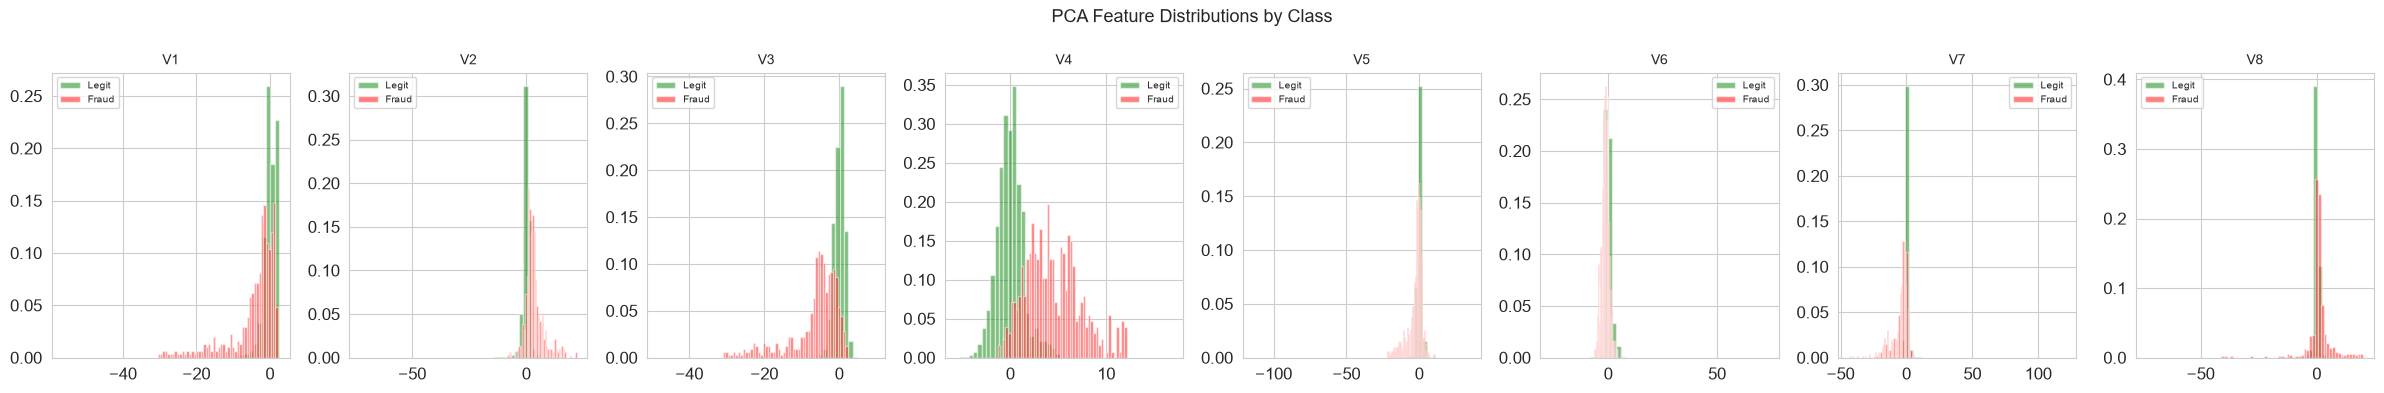

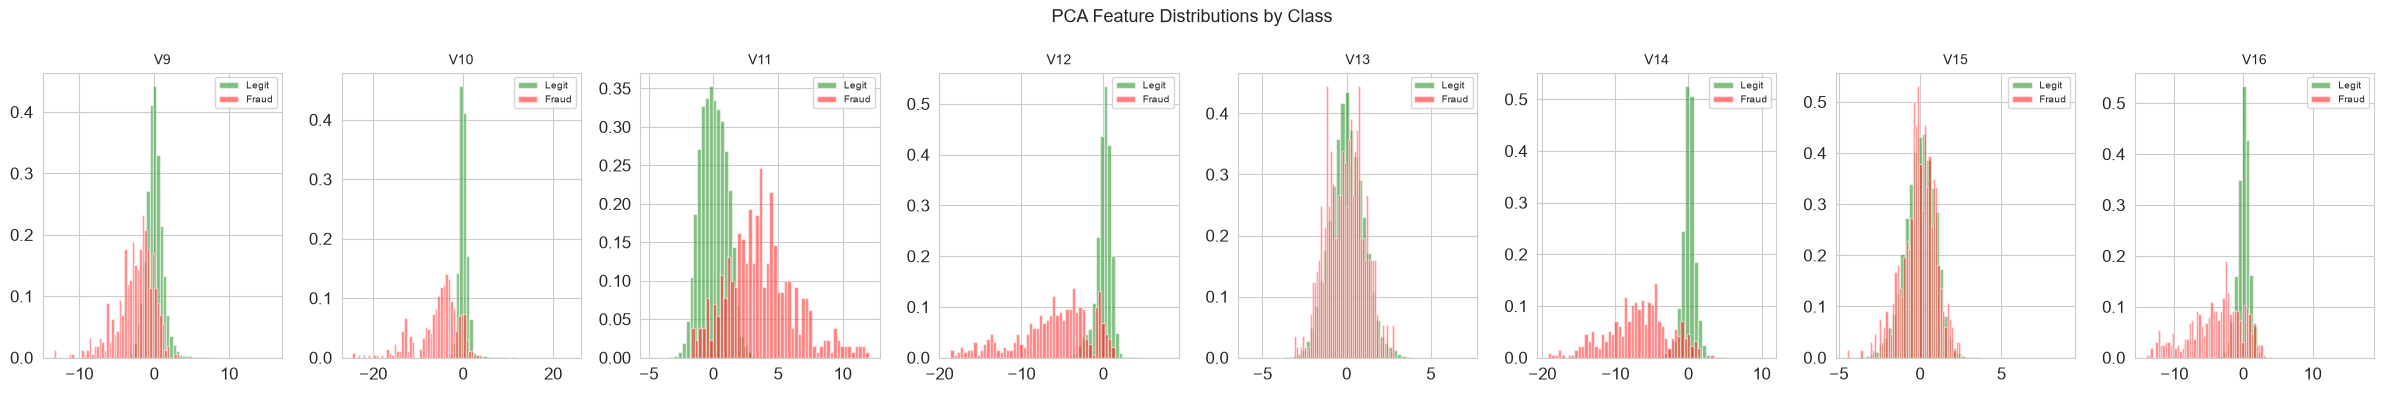

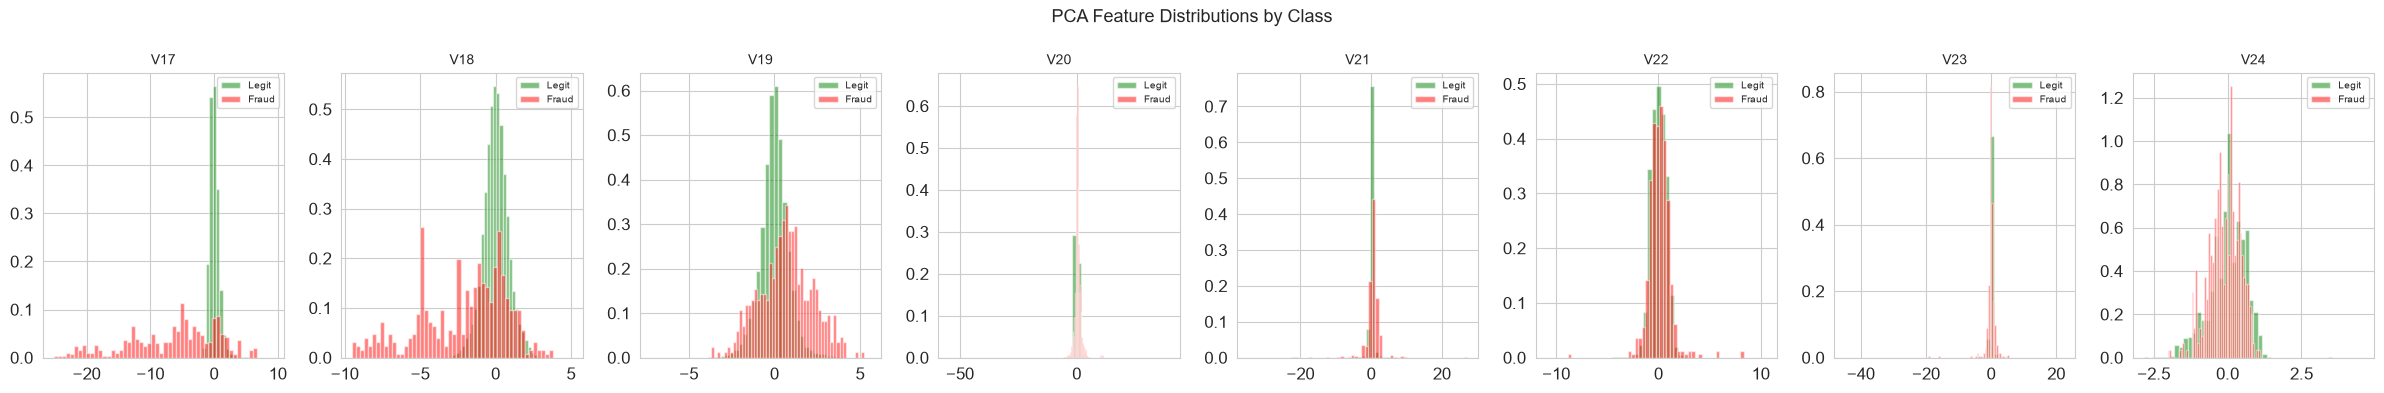

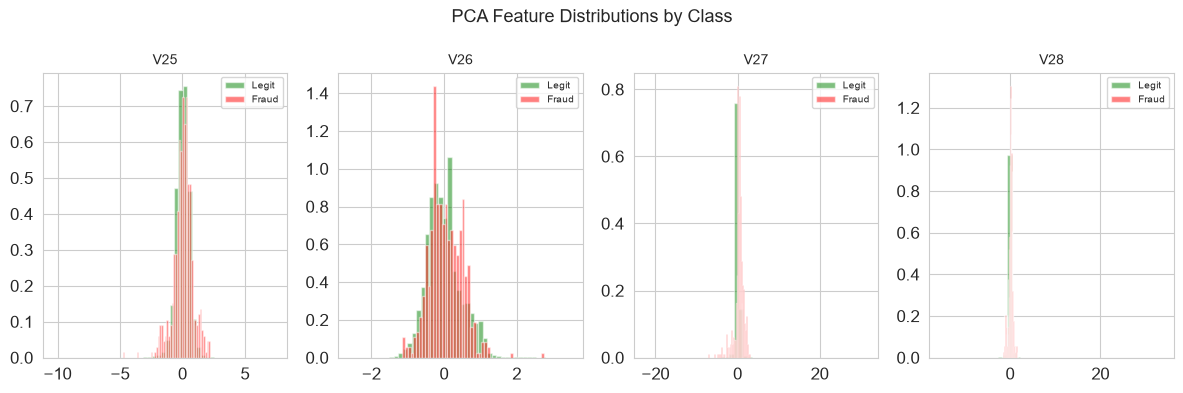

In [10]:
select_batches = [
    ["V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8"],
    ["V9", "V10", "V11", "V12", "V13", "V14", "V15", "V16"],
    ["V17", "V18", "V19", "V20", "V21", "V22", "V23", "V24"],
    ["V25", "V26", "V27", "V28"],
]

for batch in select_batches:
    n = len(batch)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, batch):
        ax.hist(df[df["Class"] == 0][col], bins=50, alpha=0.5, label="Legit", color="green", density=True)
        ax.hist(df[df["Class"] == 1][col], bins=50, alpha=0.5, label="Fraud", color="red", density=True)
        ax.set_title(col, fontsize=10)
        ax.legend(fontsize=7)
    plt.suptitle("PCA Feature Distributions by Class", fontsize=13)
    plt.tight_layout()
    plt.show()

## 6. Correlation with Target

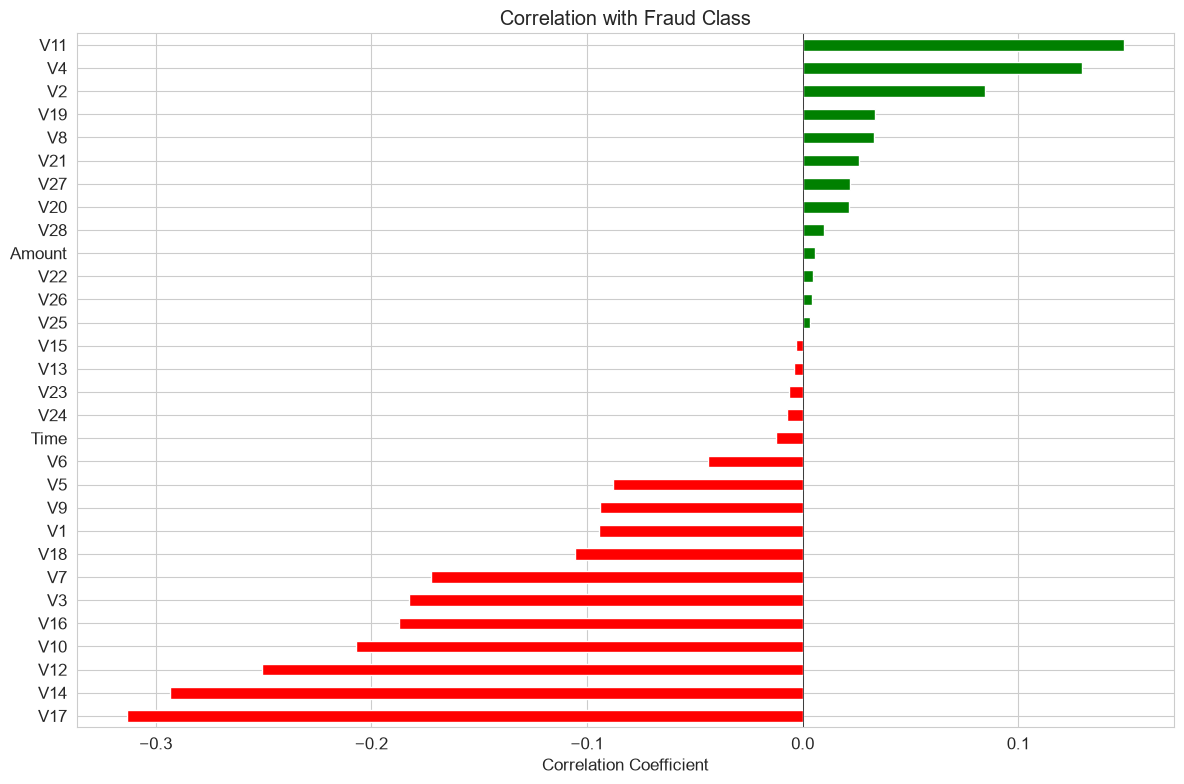


Top 5 positively correlated:
V8     0.033068
V19    0.033631
V2     0.084624
V4     0.129326
V11    0.149067
dtype: float64

Top 5 negatively correlated:
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
dtype: float64


In [11]:
correlations = df[v_cols + ["Amount", "Time"]].corrwith(df["Class"]).sort_values()

plt.figure(figsize=(12, 8))
correlations.plot.barh(
    color=["red" if x < 0 else "green" for x in correlations])
plt.title("Correlation with Fraud Class")
plt.xlabel("Correlation Coefficient")
plt.axvline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()

print("\nTop 5 positively correlated:")
print(correlations.tail(5))
print("\nTop 5 negatively correlated:")
print(correlations.head(5))

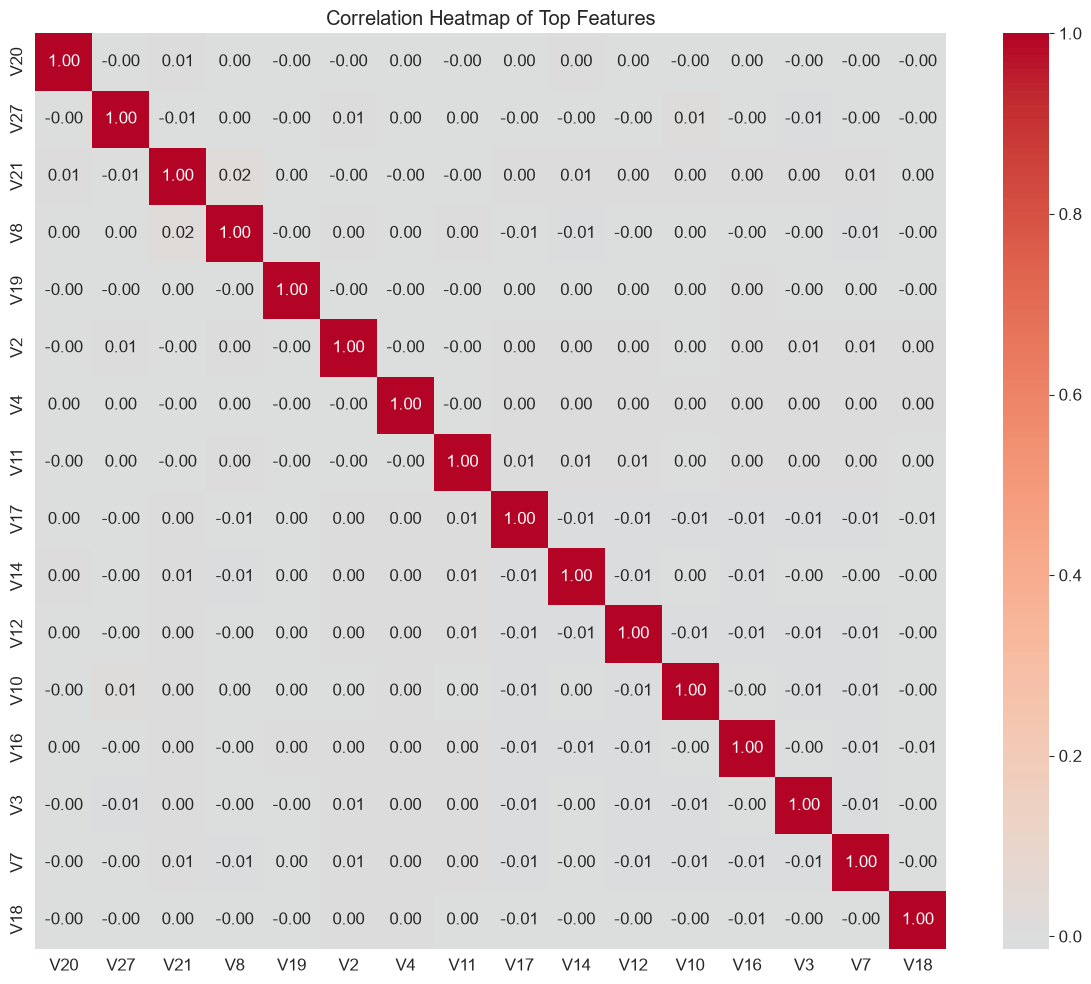

In [12]:
top_pos = correlations.tail(8).index.tolist()
top_neg = correlations.head(8).index.tolist()
top_features = top_pos + top_neg

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Heatmap of Top Features")
plt.tight_layout()
plt.show()

## 7. Variance Analysis

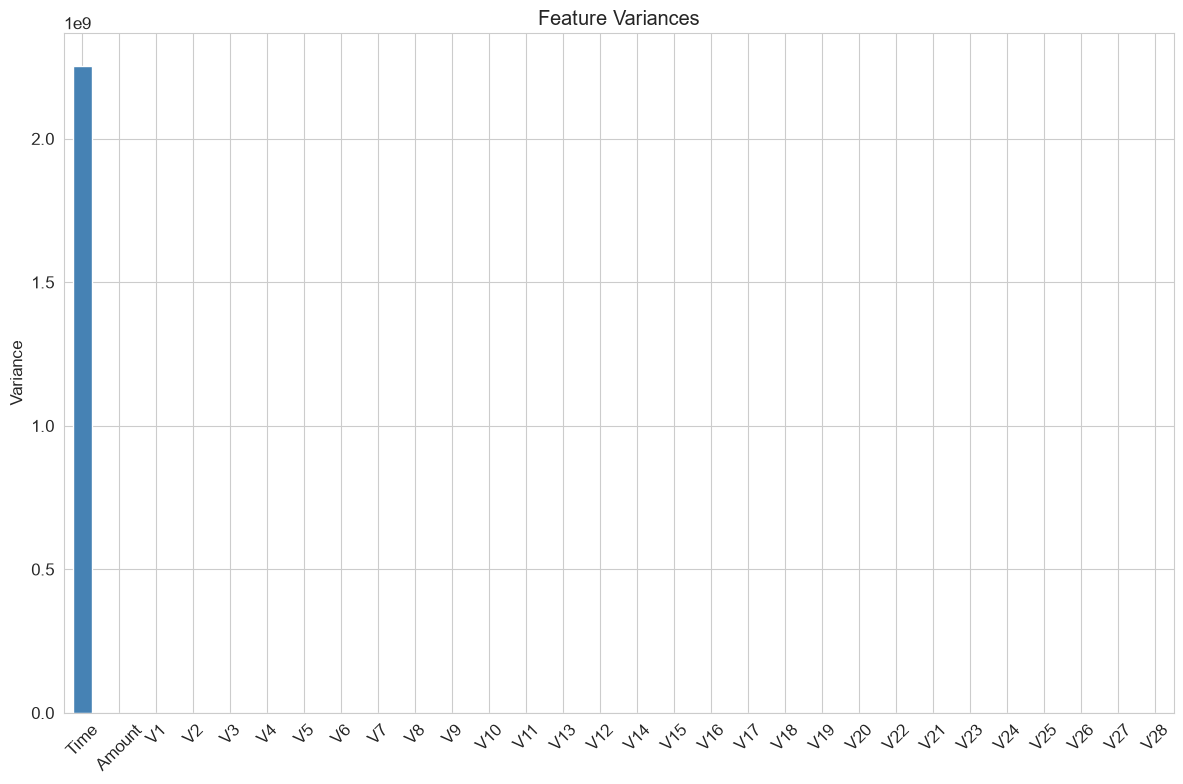

In [13]:
variances = df[v_cols + ["Amount", "Time"]].var().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
variances.plot.bar(color="steelblue")
plt.title("Feature Variances")
plt.ylabel("Variance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Outlier Analysis

In [14]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df["Amount"] < lower) | (df["Amount"] > upper)]

print(f"Amount outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Outlier range: < ${lower:.2f} or > ${upper:.2f}")
print(f"Fraud rate in outliers: {outliers['Class'].mean()*100:.2f}%")
print(f"Fraud rate in normal: {df[~df.index.isin(outliers.index)]['Class'].mean()*100:.2f}%")

Amount outliers: 31685 (11.17%)
Outlier range: < $-102.27 or > $185.38
Fraud rate in outliers: 0.27%
Fraud rate in normal: 0.15%


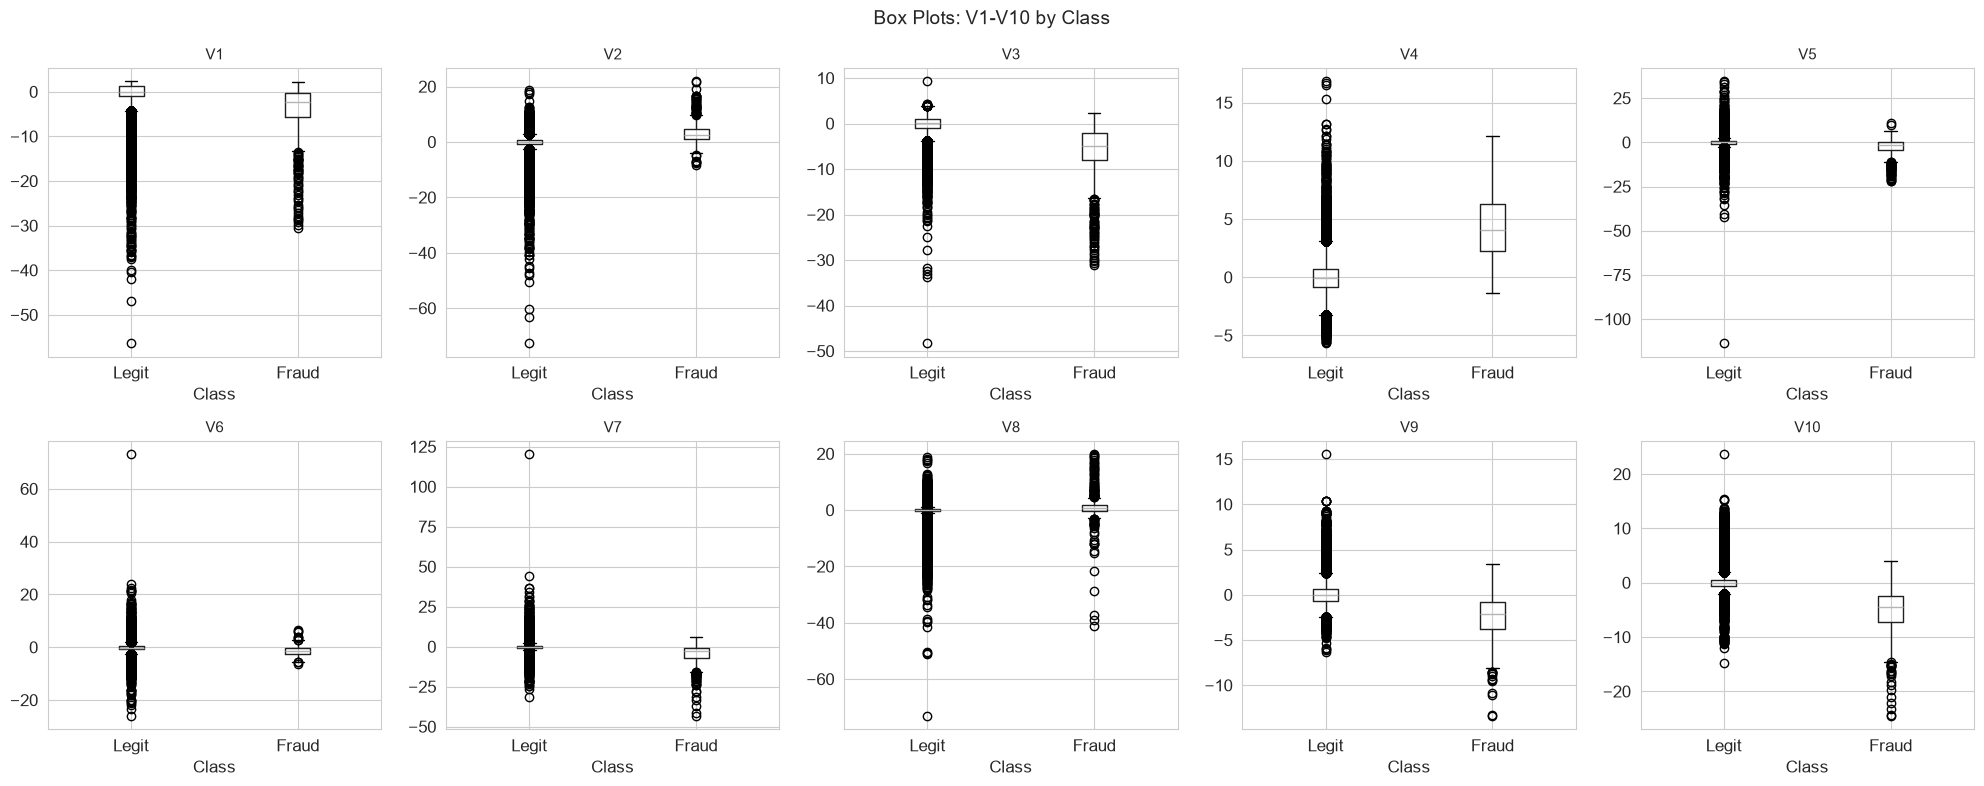

In [15]:
box_features = [f"V{i}" for i in range(1, 11)]
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flat, box_features):
    df.boxplot(column=col, by="Class", ax=ax)
    ax.set_title(col, fontsize=11)
    ax.set_xticklabels(["Legit", "Fraud"])
plt.suptitle("Box Plots: V1-V10 by Class", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Key Findings

- No missing values; some duplicates removed
- **Extreme imbalance**: ~0.17% fraud
- PCA features V4, V11, V12, V14, V17 show clearest class separation
- Amount is heavily right-skewed; log transform helps
- Time alone is not a strong fraud predictor